# Figure 5 notebook - this focuses on TCs

In [82]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
# setup all the imports
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import seaborn as sns
import extremeweatherbench as ewb
sns.set_theme(style='whitegrid')
import shapely
from pathlib import Path
import multiprocessing
import xarray as xr
from matplotlib.lines import Line2D
import cartopy.crs as ccrs  # noqa: E402
import datetime

# make the basepath - change this to your local path
basepath = Path.home() / "extreme-weather-bench-paper" / ""
basepath = str(basepath) + "/"

import src.plots.plotting_utils as plot_utils  # noqa: E402
import src.plots.results_utils as results_utils  # noqa: E402
import src.plots.atmospheric_river_utils as ar_plot_utils  # noqa: E402
import src.plots.plotting_styles as ps  # noqa: E402


In [84]:
# load in all of the events in the yaml file
print("loading in the events yaml file")
ewb_cases = ewb.cases.load_ewb_events_yaml_into_case_list()

# subset all the cases to only include the tc cases
ewb_cases = [c for c in ewb_cases if c.event_type == "tropical_cyclone"]

case_operators = ewb.cases.build_case_operators(
    ewb_cases, ewb.defaults.get_brightband_evaluation_objects()
)

loading in the events yaml file


In [85]:
# to plot the targets, we need to run the pipeline for each case and target
from joblib import Parallel, delayed  # noqa: E402
from joblib.externals.loky import get_reusable_executor  # noqa: E402

# load in all the case info (note this takes awhile in non-parallel form as it has to
# run all the target information for each case)
# this will return a list of tuples with the case id and the target dataset

print("running the pipeline for each case and target")
parallel = Parallel(n_jobs=32, return_as="generator", backend="loky")
case_operators_with_targets_established_generator = parallel(
    delayed(
        lambda co: (
            co.case_metadata.case_id_number,
            ewb.evaluate.run_pipeline(co.case_metadata, co.target),
        )
    )(case_operator)
    for case_operator in case_operators
)
case_operators_with_targets_established = list(
    case_operators_with_targets_established_generator
)
# this will throw a bunch of errors below but they're not consequential. this releases
# the memory as it shuts down the workers
get_reusable_executor().shutdown(wait=True)


running the pipeline for each case and target


/home/amy/extreme-weather-bench-paper/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [86]:
import copy

def get_target_ds(case_operator: "cases.CaseOperator") -> xr.Dataset:
    """Get the target dataset for a case operator.

    Args:
        case_operator: The case operator to get the target dataset for.

    Returns:
        The target dataset.
    """
    metric_forecast_vars, metric_target_vars = ewb.evaluate._collect_metric_variables(
        case_operator.metric_list
    )
    target_derived_outputs = ewb.evaluate._get_all_derived_output_variables(
        case_operator.target.variables
    )
    filtered_target_vars = {
        v
        for v in metric_target_vars
        if not (isinstance(v, str) and v in target_derived_outputs)
    }
    augmented_target = copy.copy(case_operator.target)
    augmented_target.variables = list(
        set(case_operator.target.variables) | filtered_target_vars
    )
    target_ds = ewb.evaluate.run_pipeline(
        case_operator.case_metadata, augmented_target
    )
    return target_ds

In [87]:
# now compute landfalls for each case (do it in parallel as it is a bit slow in serial)
all_landfalls = []
landfalls_generator = parallel(
    delayed(
        lambda co: (
            co.case_metadata.case_id_number,
            ewb.calc.find_landfalls(get_target_ds(co)['air_pressure_at_mean_sea_level'])
        )
    )(case_operator)
    for case_operator in case_operators
)
landfalls = list(landfalls_generator)

/home/amy/extreme-weather-bench-paper/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/amy/extreme-weather-bench-paper/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/amy/extreme-weather-bench-paper/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/amy/extreme-weather-bench-paper/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while s

In [88]:
# load the results back in
hres_tc_results = pd.read_pickle(basepath + 'saved_data/hres_tc_results.pkl')
pangu_tc_results = pd.read_pickle(basepath + 'saved_data/bb_pangu_tc_results.pkl')
gc_tc_results = pd.read_pickle(basepath + 'saved_data/bb_graphcast_tc_results.pkl')
aifs_tc_results = pd.read_pickle(basepath + 'saved_data/bb_aifs_tc_results.pkl')

In [ ]:
hres_tc_results.metric.unique()

In [89]:
# some of them don't actually make landfall in IBTrACS (which is odd but just ignore them for now)
no_landfalls = []
landfall_case_ids = []
landfall_info = []
for i, (case_id, landfall_da) in enumerate(landfalls):
    if (len(landfall_da.valid_time) == 0):
        print("no landfalls for case", case_id)
        no_landfalls.append(case_id)
    else:
        landfall_case_ids.append(case_id)
        landfall_info.append(landfalls[i])

len(landfall_case_ids)
len(no_landfalls)


no landfalls for case 157
no landfalls for case 166
no landfalls for case 193
no landfalls for case 213
no landfalls for case 225
no landfalls for case 228
no landfalls for case 231
no landfalls for case 245


8

In [90]:
# make the bounding boxes for the regions

# Atlantic Basin
ab_bounding_box = [-120, -45, 7, 85]
ab_bounding_box_polygon = plot_utils.get_polygon_from_bounding_box(ab_bounding_box)
ab_bounding_region = ewb.regions.BoundingBoxRegion(latitude_min=7, latitude_max=85, longitude_min=-120, longitude_max=-45)

# pacific basin
pb_bounding_box = [60, 150, -50, 50]
pb_bounding_box_polygon = plot_utils.get_polygon_from_bounding_box(pb_bounding_box)
pb_bounding_region = ewb.regions.BoundingBoxRegion(latitude_min=-50, latitude_max=50, longitude_min=60, longitude_max=150)

# break the cases into different lists
ab_subset = ewb.regions.RegionSubsetter(region=ab_bounding_region, method='intersects').subset_case_list(ewb_cases)
pb_subset = ewb.regions.RegionSubsetter(region=pb_bounding_region, method='intersects').subset_case_list(ewb_cases)
ab_case_ids = [n.case_id_number for n in ab_subset]
pb_case_ids = [n.case_id_number for n in pb_subset]

print(f'Atlantic Basin Cases: {ab_case_ids}')
print(f'Pacific Basin Cases: {pb_case_ids}')


Atlantic Basin Cases: [151, 152, 153, 154, 155, 156, 170, 172, 173, 174, 175, 176, 177, 178, 179, 180, 194, 195, 196, 197, 198, 199, 200, 201, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245]
Pacific Basin Cases: [158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 202, 203, 204, 205, 206, 207, 208, 210, 212, 225, 226, 227, 228, 229, 230, 231, 232, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256]


/home/amy/extreme-weather-bench-paper/src/plots/plotting_utils.py:1319: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower left", fontsize=12)
/home/amy/extreme-weather-bench-paper/src/plots/plotting_utils.py:1319: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower left", fontsize=12)


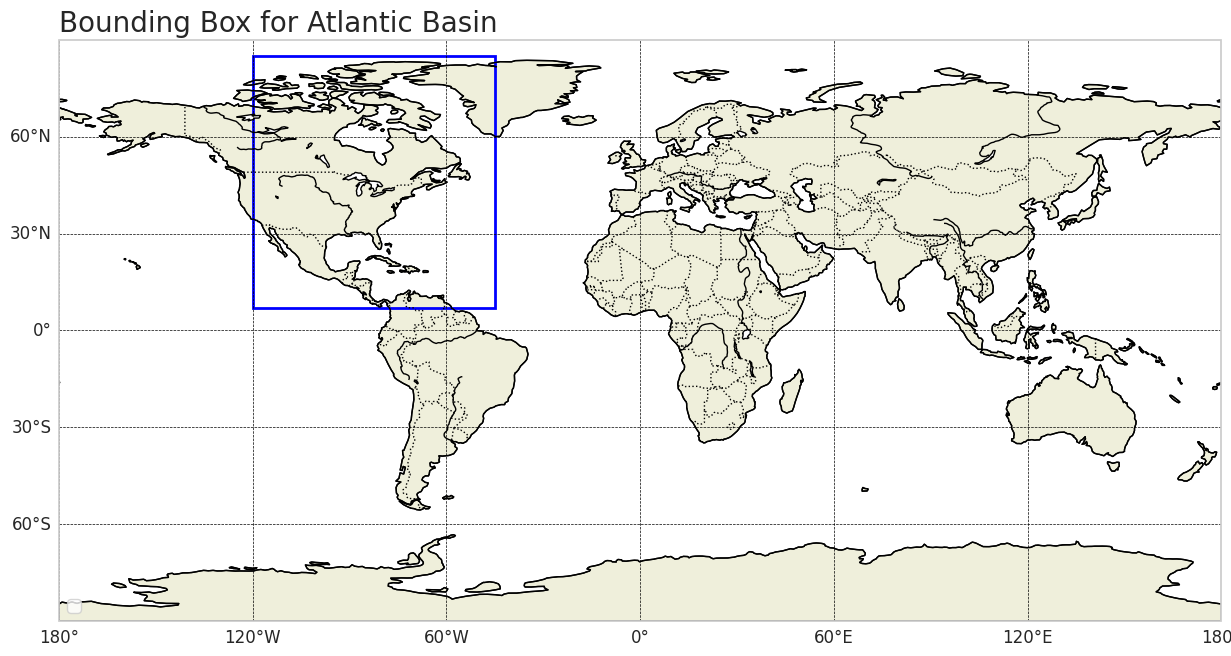

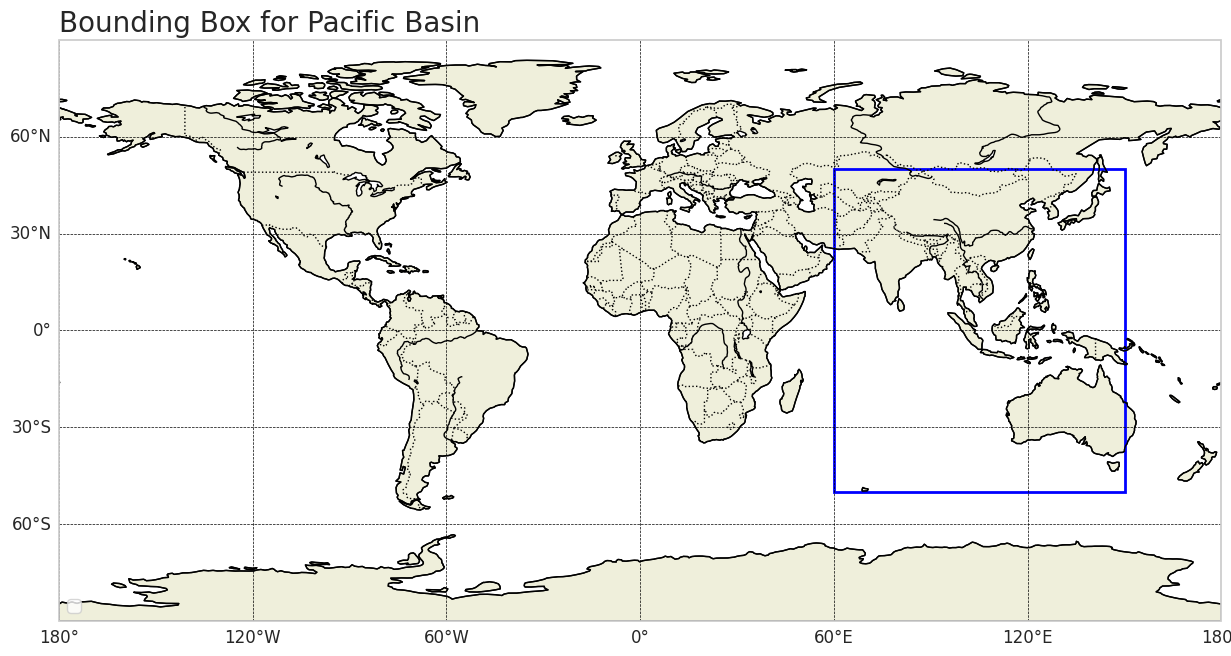

In [91]:
from shapely.geometry import Polygon

# helper functions to make the main plotting function cleaner
# helper function to convert a bounding box tuple to a shapely Polygon
def get_polygon_from_bounding_box(bounding_box):
    """Convert a bounding box tuple to a shapely Polygon."""
    if bounding_box is None:
        return None
    left_lon, right_lon, bot_lat, top_lat = bounding_box
    return Polygon(
        [
            (left_lon, bot_lat),
            (right_lon, bot_lat),
            (right_lon, top_lat),
            (left_lon, top_lat),
            (left_lon, bot_lat),
        ]
    )

# plot the bounding box we will use for the non-event days
bounding_box_polygon = get_polygon_from_bounding_box(ab_bounding_box)
plot_utils.plot_boxes([bounding_box_polygon], [], title="Bounding Box for Atlantic Basin")

# plot the bounding box for the pacific basin
bounding_box_polygon = get_polygon_from_bounding_box(pb_bounding_box)
plot_utils.plot_boxes([bounding_box_polygon], [], title="Bounding Box for Pacific Basin")


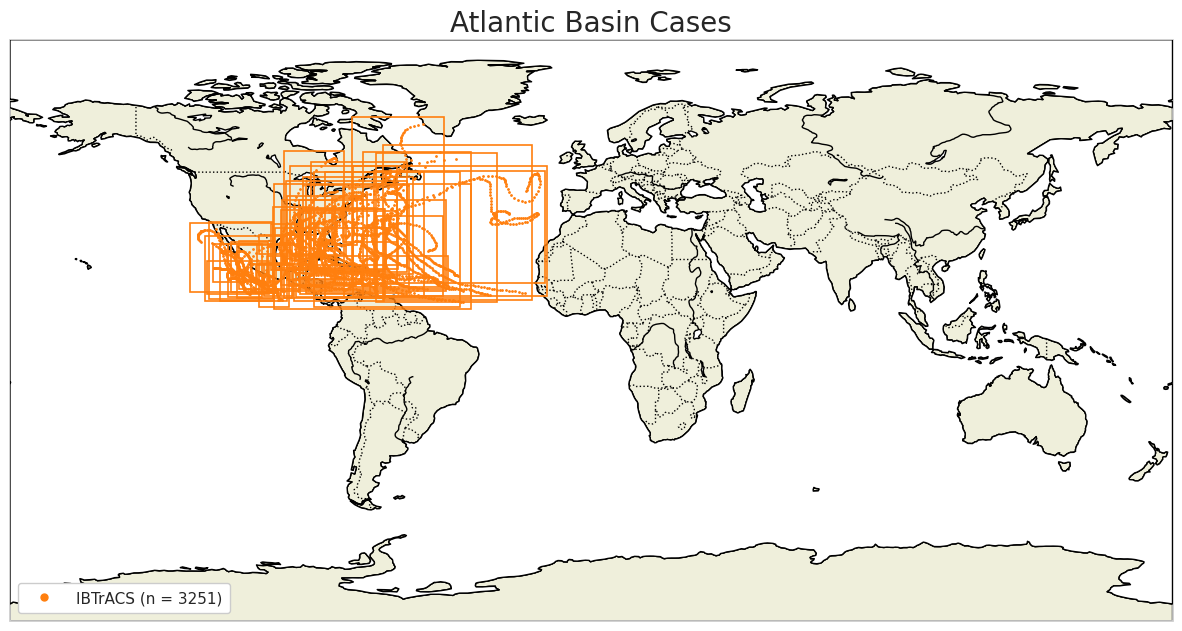

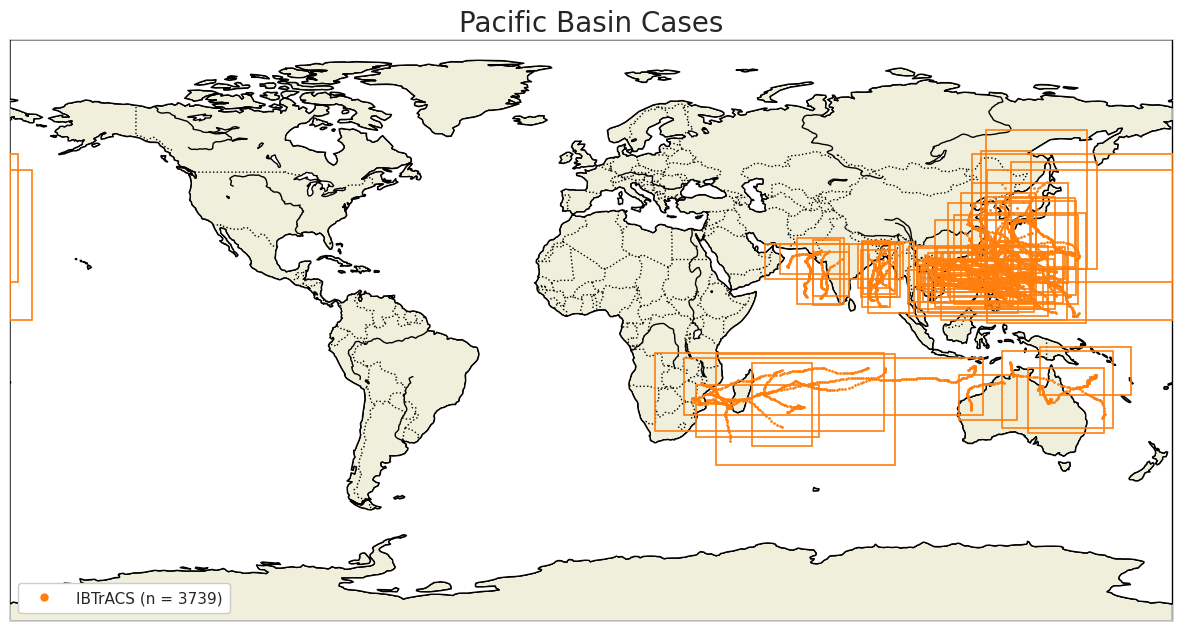

In [92]:
# plot the cases inside the bounding boxes
plot_utils.plot_all_cases_and_obs(ab_subset, event_type="tropical_cyclone", 
    targets=case_operators_with_targets_established, title="Atlantic Basin Cases")
plot_utils.plot_all_cases_and_obs(pb_subset, event_type="tropical_cyclone", 
    targets=case_operators_with_targets_established, title="Pacific Basin Cases")


In [93]:
ida_list = [218]
step1 = hres_tc_results[hres_tc_results.metric == 'landfall_intensity_mae']
step2 = step1[step1.forecast_source == ps.hres_ifs_settings['forecast_source']]
step3 = step2[step2.target_source == 'IBTrACS']
step4 = step3[step3.target_variable == 'surface_wind_speed']
step5 = step4[step4.case_id_number.isin(ida_list)]

# lead_time_days = [1, 3, 5]

# lead_times = [
#         np.timedelta64(lead_time_days[i], "D") for i in range(len(lead_time_days))
# ]

# subset = hres_tc_results[
#             (hres_tc_results["forecast_source"] == ps.hres_ifs_settings['forecast_source'])
#             & (hres_tc_results["target_source"] == 'IBTrACS')
#             & (hres_tc_results["metric"] == 'landfall_time_me')
#             & (hres_tc_results["case_id_number"].isin(ida_list))
#         ]

# # add lead_time column: for each row, end_date - init_time (on the main subset)
# step6 = step5.copy()
# step6["lead_time"] = step6["case_id_number"].map(end_date_by_case) - pd.to_datetime(step6["init_time"])

# # step6 = step5.loc[np.isin(step5["lead_time"].values, lead_times)]

# # step7 = step6.set_index(["lead_time", "case_id_number"]).sort_index()
# # step8 = step7.to_xarray()


In [94]:
step5

,value,lead_time,init_time,target_variable,metric,forecast_source,target_source,case_id_number,event_type
1056,19.432947,NaN,2021-08-25 12:00:00,surface_wind_speed,landfall_intensity_mae,ECMWF HRES,IBTrACS,218,tropical_cyclone
1057,6.107342,NaN,2021-08-26 00:00:00,surface_wind_speed,landfall_intensity_mae,ECMWF HRES,IBTrACS,218,tropical_cyclone
1058,11.149486,NaN,2021-08-26 12:00:00,surface_wind_speed,landfall_intensity_mae,ECMWF HRES,IBTrACS,218,tropical_cyclone
1059,10.985334,NaN,2021-08-27 00:00:00,surface_wind_speed,landfall_intensity_mae,ECMWF HRES,IBTrACS,218,tropical_cyclone
1060,12.280451,NaN,2021-08-27 12:00:00,surface_wind_speed,landfall_intensity_mae,ECMWF HRES,IBTrACS,218,tropical_cyclone


In [63]:
for i, (case_id, landfall_da) in enumerate(landfalls):
    if (case_id == 218):
        print(landfall_da)

<xarray.DataArray 'value' (landfall: 5)> Size: 40B
array([98712.47390795, 98800.        , 93105.58701953, 99700.        ,
       99600.        ])
Coordinates:
  * landfall    (landfall) int64 40B 10 11 27 57 60
    latitude    (landfall) float64 40B 21.55 22.37 29.11 41.26 44.16
    longitude   (landfall) float64 40B -82.6 -83.17 -90.21 -70.11 -66.19
    valid_time  (landfall) datetime64[ns] 40B 2021-08-27T18:22:27.182058711 ....


In [102]:
lead_time_days = [1, 3, 5]
foo = results_utils.subset_results_to_xarray_by_init_time_tropical_cyclone(ewb_cases, hres_tc_results, 
    forecast_source=ps.hres_ifs_settings['forecast_source'], metric='landfall_time_me', 
    target_source='IBTrACS', lead_time_days=lead_time_days, case_ids=[218], 
    target_variable='surface_wind_speed', landfalls=landfalls)

<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.


In [103]:
foo

<xarray.Dataset> Size: 72B
Dimensions:          (lead_time: 1, case_id_number: 1)
Coordinates:
  * lead_time        (lead_time) timedelta64[ns] 8B 1 days
  * case_id_number   (case_id_number) int64 8B 218
Data variables:
    value            (lead_time, case_id_number) object 8B 33.955545829756666
    init_time        (lead_time, case_id_number) datetime64[ns] 8B 2021-08-27
    target_variable  (lead_time, case_id_number) object 8B 'surface_wind_speed'
    metric           (lead_time, case_id_number) object 8B 'landfall_time_me'
    forecast_source  (lead_time, case_id_number) object 8B 'ECMWF HRES'
    target_source    (lead_time, case_id_number) object 8B 'IBTrACS'
    event_type       (lead_time, case_id_number) object 8B 'tropical_cyclone'

In [107]:
# for landfall_intensity do both target variables: surface_wind_speed and air_pressure_at_mean_sea_level
# for all other metrics, they are equal so just use surface_wind_speed
# 

def get_error_array_for_heatmap(case_list, results_array, hres_results, forecast_sources, 
    target_source, metric_strs, lead_time_days, higher_is_better_list, case_ids=None, target_variable=None, landfalls=None):
    """
    This function takes in an array of results and parameters to say which results to grab and returns 
    error arrays and relative arrays for global, north america, and europe.
    """
    # now make the array for the scorecard
    rel_error = {}
    error = {}

    for i, metric in enumerate(metric_strs):
        # initialize the arrays
        rel_error[metric] = np.zeros((len(results_array), len(lead_time_days)))
        error[metric] = np.zeros((len(results_array), len(lead_time_days)))

        higher_is_better = higher_is_better_list[i]

        for j, results_df in enumerate(results_array):
            my_mean, my_relative_error = results_utils.compute_relative_error_tropical_cyclone(
                ewb_cases=case_list, 
                results_df=results_df, 
                forecast_source=forecast_sources[j], 
                comparison_results_df=hres_results, 
                comparison_forecast_source=ps.hres_settings['forecast_source'], 
                target_source=target_source[i], 
                metric=metric, lead_time_days=lead_time_days, 
                case_ids=case_ids,
                higher_is_better=higher_is_better, target_variable=target_variable[i], landfalls=landfalls)

            if (len(my_mean) == 0):
                print(f'metric: {metric}, forecast_source: {forecast_sources[j]}')
                print(results_df)

            error[metric][j, :] = my_mean
            rel_error[metric][j, :] = my_relative_error


    return error, rel_error

# setup for the scorecard
# Grab means for each metric for each model
tc_metric_str = ['landfall_intensity_mae', 'landfall_intensity_mae', 'landfall_time_me', 'landfall_displacement']
tc_display_str = ['Landfall Intensity wind speed MAE', 'Landfall Intensity pressure MAE', 'Landfall Time ME', 'Landfall Displacement']
target_variable = ['surface_wind_speed', 'air_pressure_at_mean_sea_level', 'surface_wind_speed', 'surface_wind_speed']
tc_metric_higher_is_better = [False, False, False, False]
target_source = ['IBTrACS', 'IBTrACS', 'IBTrACS', 'IBTrACS']

lead_time_days = [1, 3, 5, 7, 10]

tc_results_array = [hres_tc_results, gc_tc_results, pangu_tc_results, aifs_tc_results]
forecast_source = [ps.hres_ifs_settings['forecast_source'],
    ps.bb_graphcast_settings['forecast_source'],
    ps.bb_pangu_settings['forecast_source'],
    ps.bb_aifs_settings['forecast_source']]

(global_tc_error, global_rel_tc_error) = get_error_array_for_heatmap(ewb_cases, 
    tc_results_array, hres_tc_results, forecast_source, target_source, tc_metric_str, 
    lead_time_days, tc_metric_higher_is_better, target_variable=target_variable, landfalls=landfalls)
(ab_tc_error, ab_rel_tc_error) = get_error_array_for_heatmap(ewb_cases, tc_results_array, 
    hres_tc_results, forecast_source, target_source, tc_metric_str, lead_time_days, 
    tc_metric_higher_is_better, case_ids=ab_case_ids, target_variable=target_variable, landfalls=landfalls)
(pb_tc_error, pb_rel_tc_error) = get_error_array_for_heatmap(ewb_cases, tc_results_array, 
    hres_tc_results, forecast_source, target_source, tc_metric_str, lead_time_days, 
    tc_metric_higher_is_better, case_ids=pb_case_ids, target_variable=target_variable, landfalls=landfalls)
(ida_tc_error, ida_rel_tc_error) = get_error_array_for_heatmap(ewb_cases, tc_results_array, 
    hres_tc_results, forecast_source, target_source, tc_metric_str, lead_time_days, 
    tc_metric_higher_is_better, case_ids=[218], target_variable=target_variable, landfalls=landfalls)




<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<

In [108]:
ida_tc_error

{'landfall_intensity_mae': array([[1603.88247068, 1603.88247068, 1603.88247068, 1603.88247068,
         1603.88247068],
        [   0.        ,    0.        ,    0.        ,    0.        ,
            0.        ],
        [1202.02180065, 1202.02180065, 1202.02180065, 1202.02180065,
         1202.02180065],
        [   0.        ,    0.        ,    0.        ,    0.        ,
            0.        ]]),
 'landfall_time_me': array([[33.95554583, 33.95554583, 33.95554583, 33.95554583, 33.95554583],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
        [26.91434713, 26.91434713, 26.91434713, 26.91434713, 26.91434713],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ]]),
 'landfall_displacement': array([[725.07589794, 725.07589794, 725.07589794, 725.07589794,
         725.07589794],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ],
        [671.31179913, 671.31179913, 671.31179913, 671.31179913,
      

In [104]:
(my_tc_error, my_rel_tc_error) = get_error_array_for_heatmap(ewb_cases, tc_results_array, 
    hres_tc_results, forecast_source, target_source, tc_metric_str, lead_time_days, 
    tc_metric_higher_is_better, case_ids=[218], target_variable=target_variable, landfalls=landfalls)

<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
/home/amy/extreme-weather-bench-paper/.venv/lib/python3.13/site-packages/xarray/computation/nanops.py:116: RuntimeWarning: invalid value encountered in divide
  data = data / (valid_count - ddof)
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning:

In [105]:
my_tc_error

{'landfall_intensity_mae': array([[1603.88247068, 1603.88247068, 1603.88247068],
        [   0.        ,    0.        ,    0.        ],
        [1202.02180065, 1202.02180065, 1202.02180065],
        [   0.        ,    0.        ,    0.        ]]),
 'landfall_time_me': array([[33.95554583, 33.95554583, 33.95554583],
        [ 0.        ,  0.        ,  0.        ],
        [26.91434713, 26.91434713, 26.91434713],
        [ 0.        ,  0.        ,  0.        ]]),
 'landfall_displacement': array([[725.07589794, 725.07589794, 725.07589794],
        [  0.        ,   0.        ,   0.        ],
        [671.31179913, 671.31179913, 671.31179913],
        [  0.        ,   0.        ,   0.        ]])}

In [70]:
my_mean, my_relative_error = results_utils.compute_relative_error_tropical_cyclone(
    ewb_cases=ewb_cases, 
    results_df=hres_tc_results, 
    forecast_source=ps.hres_ifs_settings['forecast_source'], 
    comparison_results_df=hres_tc_results, 
    comparison_forecast_source=ps.hres_settings['forecast_source'], 
    target_source=['IBTrACS'], 
    metric='landfall_time_me', 
    lead_time_days=lead_time_days, 
    case_ids=[215],
    higher_is_better=False, target_variable='landfall_time_me', landfalls=landfalls)

ValueError: ('Lengths must match to compare', (4410,), (1,))

In [100]:
lead_time_days = [1, 3, 5, 7, 10]
(my_tc_error, my_rel_tc_error) = get_error_array_for_heatmap(
    case_list=ewb_cases, 
    results_array=[hres_tc_results], 
    hres_results=hres_tc_results, 
    forecast_sources=[ps.hres_ifs_settings['forecast_source']], 
    target_source=['IBTrACS'], 
    metric_strs=['landfall_time_me'], 
    lead_time_days=lead_time_days, 
    higher_is_better_list=[False], 
    case_ids=[218], 
    target_variable=target_variable,
    landfalls=landfalls)

# foo = results_utils.subset_results_to_xarray_by_init_time_tropical_cyclone(ewb_cases, hres_tc_results, 
#     forecast_source=ps.hres_ifs_settings['forecast_source'], metric='landfall_time_me', 
#     target_source='IBTrACS', lead_time_days=lead_time_days, case_id_list=[218, 155], 
#     target_variable='surface_wind_speed', landfalls=landfalls)

<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.


In [101]:
my_tc_error

{'landfall_time_me': array([[33.95554583, 33.95554583, 33.95554583, 33.95554583, 33.95554583]])}

(32, 26.0)
plotting the cases for each event type


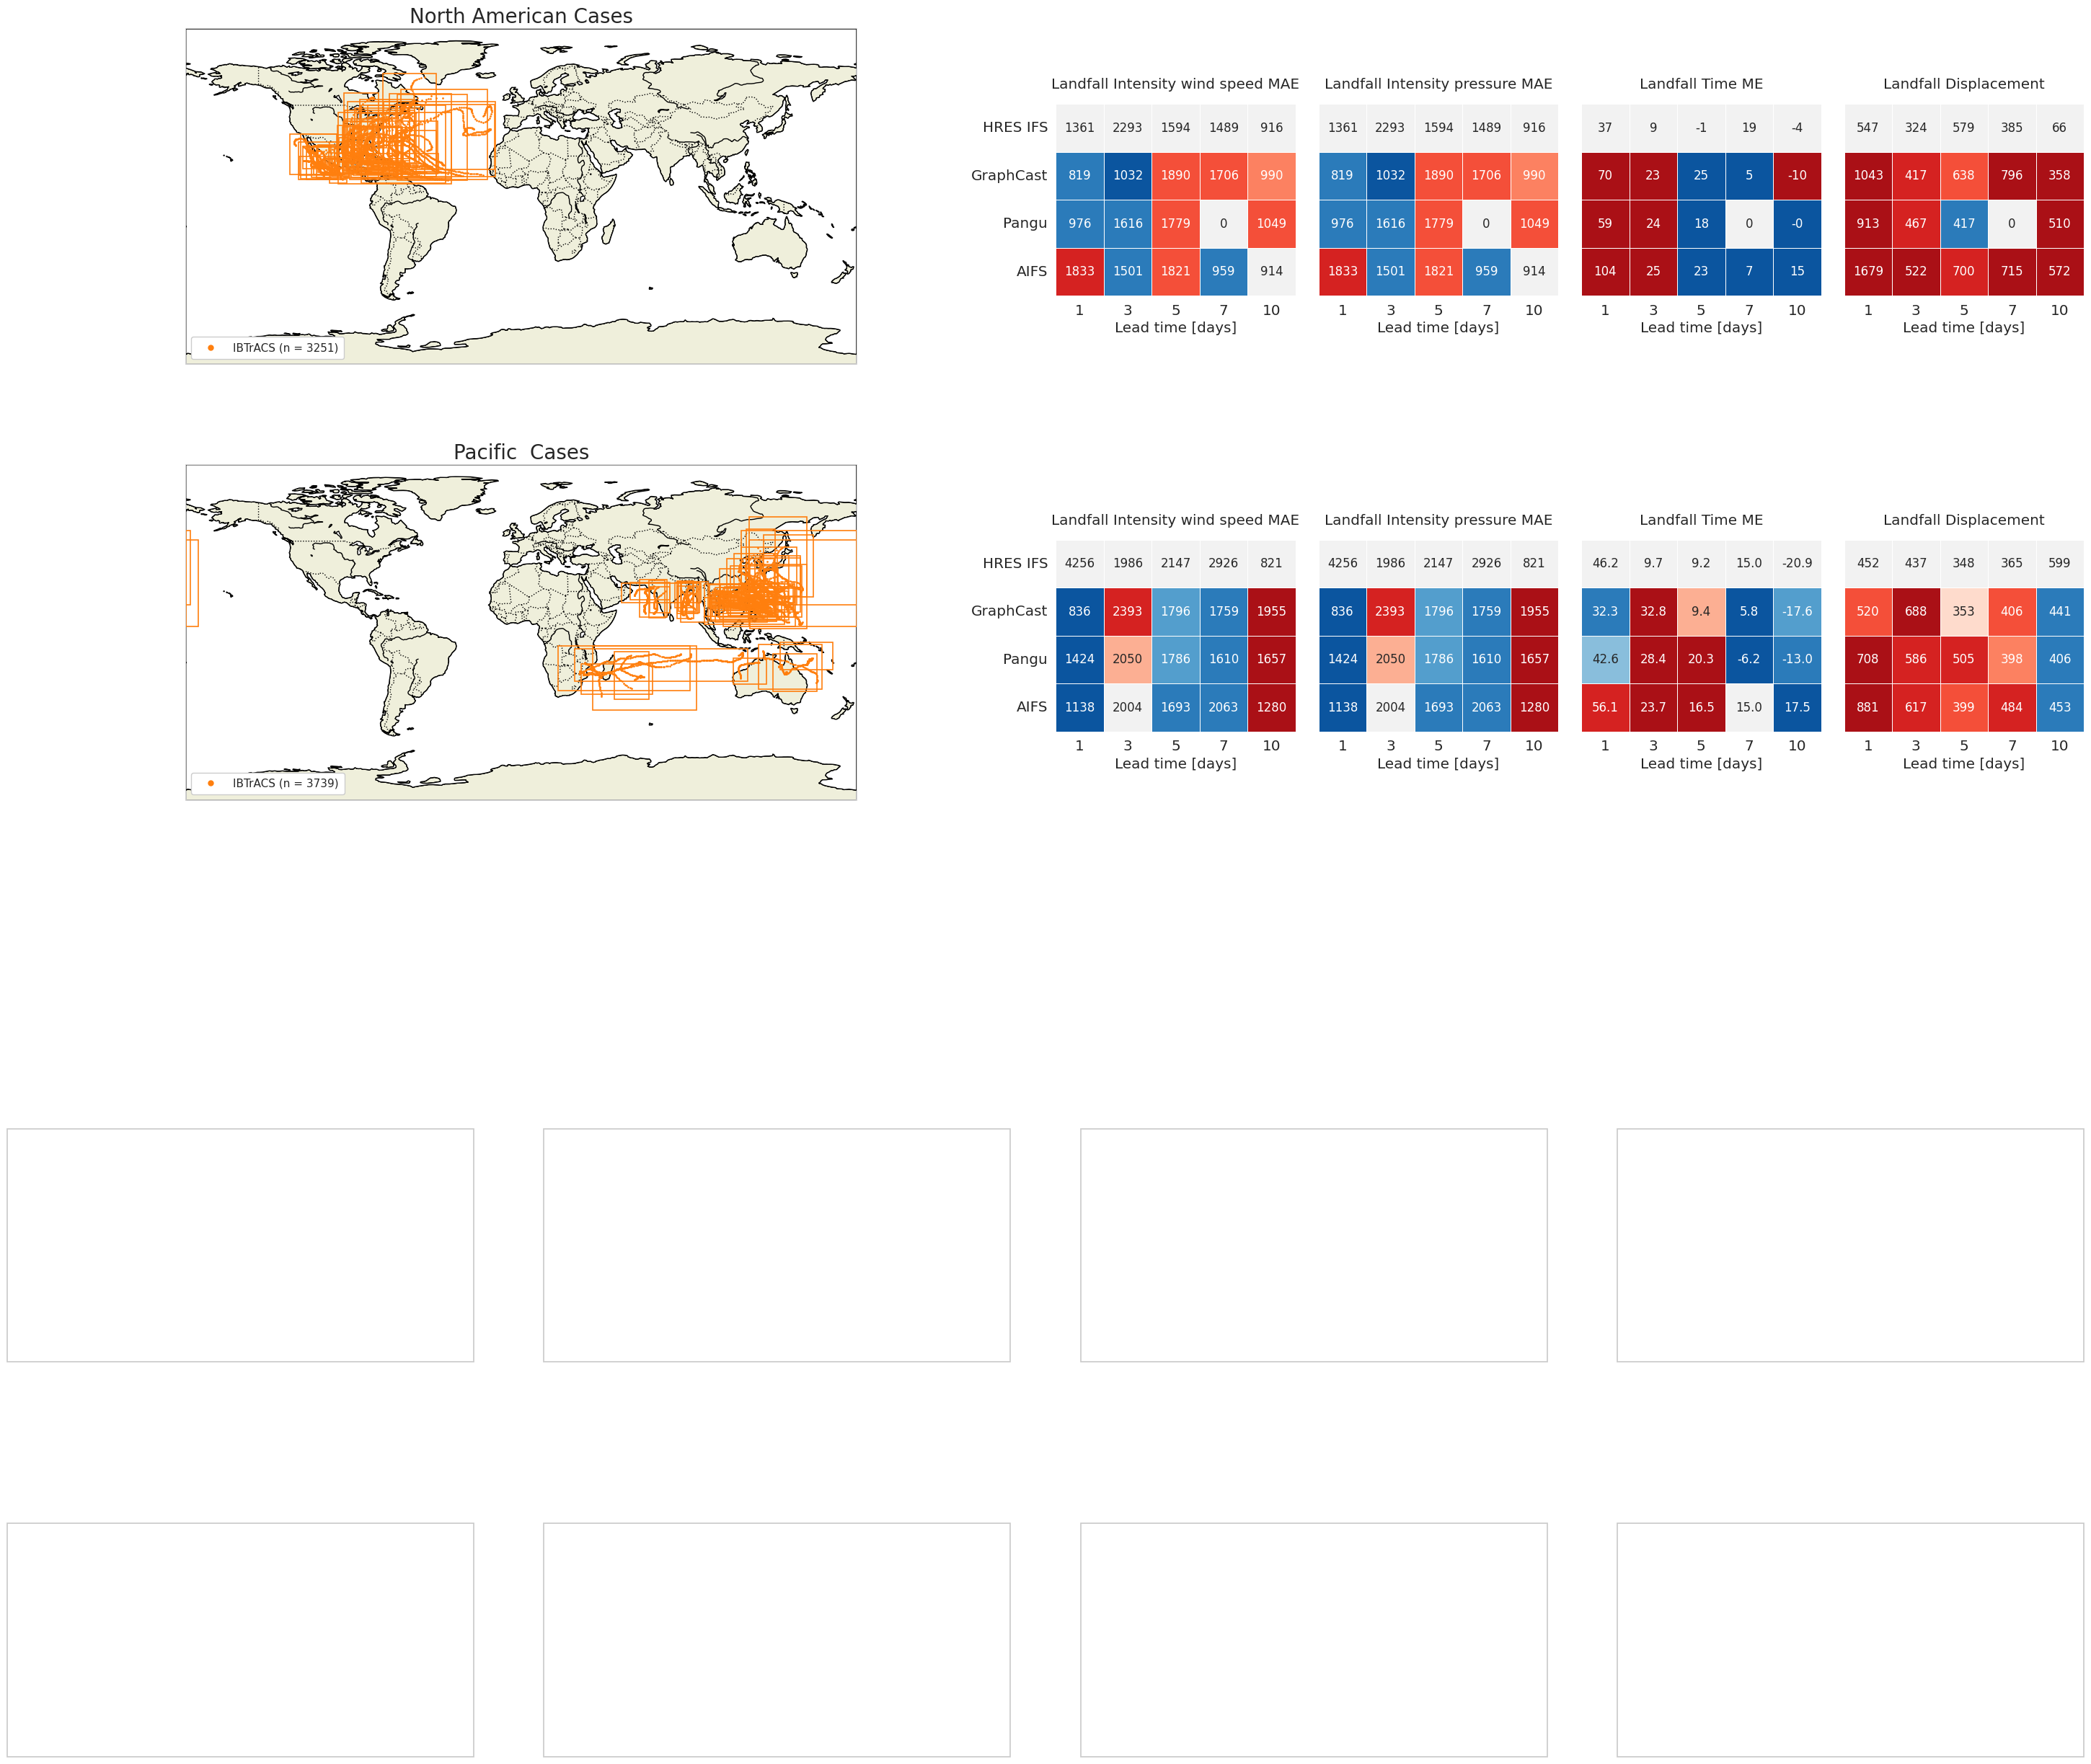

In [96]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

n_rows_top = 2
n_rows_bottom = 2
n_rows = n_rows_top + n_rows_bottom
n_cols_top = 2  # Columns for top 3 rows
n_cols_bottom = 4  # Columns for bottom 2 rows (more Cartopy plots)
figsize = (8 * max(n_cols_top, n_cols_bottom), 6.5 * n_rows)
print(figsize)

# Create figure first
fig = plt.figure(figsize=figsize)

# Main GridSpec: 6 rows, use max columns for layout
# Top 4 rows will use 2 columns, bottom 2 rows will use 4 columns
gs_main = GridSpec(n_rows, 1, figure=fig, left=0.05, right=0.95, top=0.98, bottom=0.02,
    wspace=.1, hspace=1)

# Create subplots for top 4 rows (2 columns each)
gs_top = GridSpecFromSubplotSpec(n_rows_top, n_cols_top, subplot_spec=gs_main[0:n_rows_top, 0],
                                  wspace=0.02, hspace=0.3,
                                  width_ratios=[1, 1])

# Create subplots for bottom 2 rows (4 columns each - all Cartopy)
gs_bottom = GridSpecFromSubplotSpec(n_rows_bottom, n_cols_bottom, subplot_spec=gs_main[n_rows_top:n_rows, 0],
                                     wspace=0.15, hspace=0.05)

# Create all subplots - initialize as array with shape (n_rows, max_cols)
max_cols = max(n_cols_top, n_cols_bottom)
axs = np.empty((n_rows, max_cols), dtype=object)

# Top n_rows_top rows: 2 columns (Cartopy on left, regular on right)
for i in range(n_rows_top):
    # Left column: Cartopy
    ax_cartopy = fig.add_subplot(gs_top[i, 0], projection=ccrs.PlateCarree())
    axs[i,0] = ax_cartopy

    # Right column: Regular matplotlib
    ax_regular = fig.add_subplot(gs_top[i, 1])
    axs[i,1] = ax_regular

# Bottom n_rows_bottom rows: 4 columns (all Cartopy)
for i in range(n_rows_bottom):
    for j in range(n_cols_bottom):
        ax_cartopy = fig.add_subplot(gs_bottom[i, j], projection=ccrs.PlateCarree())
        axs[i+n_rows_top,j] = ax_cartopy


# the left hand column of figure one shows all of the cases for each event type
# plot the cases for each event type
print("plotting the cases for each event type")

# plot the cases for north america
plot_utils.plot_all_cases_and_obs(
    ab_subset, 
    event_type="tropical_cyclone", 
    targets=case_operators_with_targets_established, 
    title="North American Cases",
    ax=axs[0, 0],
)
plot_utils.plot_all_cases_and_obs(
    pb_subset, 
    event_type="tropical_cyclone", 
    targets=case_operators_with_targets_established, 
    title="Pacific  Cases",
    ax=axs[1, 0],
)

# plot the heatmaps for each of the subareas
tc_settings = {}
tc_settings["subplot_titles"] = tc_display_str
tc_settings["metric_str"] = tc_metric_str
tc_settings["lead_time_days"] = lead_time_days
tc_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

# second column of figure 2 shows the scorecard
scorecard_mappable = plot_utils.plot_heatmap(
    ab_rel_tc_error,
    ab_tc_error,
    tc_settings,
    ax=axs[0, 1],
    return_mappable=True,
)

plot_utils.plot_heatmap(
    pb_rel_tc_error,
    pb_tc_error,
    tc_settings,
    ax=axs[1, 1],
)

# plot_utils.plot_heatmap(
#     eu_rel_ar_error,
#     eu_ar_error,
#     ar_settings,
#     ax=axs[2, 1],
# )

# plot_utils.plot_heatmap(
#     au_rel_ar_error,
#     au_ar_error,
#     ar_settings,
#     ax=axs[3, 1],
# )

# # plot the colorbar to the right of the heatmaps
# plot_utils.add_scorecard_colorbar_right(
#     fig,
#     scorecard_mappable,
#     [axs[i, 1] for i in range(4)],
#     n_subplots=4,
# )

# # now plot the ar case studies
# my_id = 113
# lead_time_hours = 72

# era5_ivt, era5_ar_mask = ar_plot_utils.select_ivt_and_maks_era5(era5_graphics[my_id, "ivt"])
# hres_ivt, hres_ar_mask = ar_plot_utils.select_ivt_and_maks(hres_graphics[my_id, "ivt"], lead_time_hours)
# gc_ivt, gc_ar_mask = ar_plot_utils.select_ivt_and_maks(gc_graphics[my_id, "ivt"], lead_time_hours)
# pangu_ivt, pangu_ar_mask = ar_plot_utils.select_ivt_and_maks(pangu_graphics[my_id, "ivt"], lead_time_hours)
# aifs_ivt, aifs_ar_mask = ar_plot_utils.select_ivt_and_maks(aifs_graphics[my_id, "ivt"], lead_time_hours)

# # setup a four panel subplot with cartopy subfigures using GridSpec
# ar_plot_utils.plot_ar_mask_single_timestep(ivt_data=era5_ivt, ar_mask=era5_ar_mask, 
#     title="ERA5", ax=axs[4,0], colorbar=False, show_axes=True)

# ar_plot_utils.plot_ar_mask_single_timestep(ivt_data=hres_ivt, ar_mask=hres_ar_mask, 
#     title="HRES", ax=axs[4,1], colorbar=False)

# ar_plot_utils.plot_ar_mask_single_timestep(ivt_data=gc_ivt, ar_mask=gc_ar_mask, 
#     title="GraphCast", ax=axs[4,2], colorbar=False)

# ar_plot_utils.plot_ar_mask_single_timestep(ivt_data=pangu_ivt, ar_mask=pangu_ar_mask, 
#     title="Pangu", ax=axs[4,3], colorbar=False)

# ar_plot_utils.plot_ar_mask_single_timestep(ivt_data=aifs_ivt, ar_mask=aifs_ar_mask, 
#     title="AIFS", ax=axs[4,4], colorbar=False)

# # put a title on the 5th row
# # Get the position from row 5 axes to position title above it
# # Use the first axes in row 5 to get position (now that it's been plotted)
# ax_row5 = axs[4, 0]
# pos_row5 = ax_row5.get_position()
# # Position title above row 5, centered
# # get_position returns a Bbox in figure coordinates (0-1)
# title_y_fig = pos_row5.y1 + 0.015  # Position slightly above row 5 top edge
# valid_time = hres_graphics[my_id, "ivt"].integrated_vapor_transport.valid_time[0].values
# # convert the valid time to a datetime object
# valid_time_dt = pd.to_datetime(valid_time)
# # Use strftime() to format the string
# valid_time_str = valid_time_dt.strftime('%m/%d/%Y, %H:%M')
# fig.text(0.5, title_y_fig, f"Case id {my_id}, Valid Time: {valid_time_str}, Lead Time: {lead_time_hours} hours", 
#          size=32, ha='center', va='bottom', transform=fig.transFigure)


# # now plot the ar case studies
# my_id = 116
# lead_time_hours = 72
# era5_ivt, era5_ar_mask = ar_plot_utils.select_ivt_and_maks_era5(era5_graphics[my_id, "ivt"])
# hres_ivt, hres_ar_mask = ar_plot_utils.select_ivt_and_maks(hres_graphics[my_id, "ivt"], lead_time_hours)
# gc_ivt, gc_ar_mask = ar_plot_utils.select_ivt_and_maks(gc_graphics[my_id, "ivt"], lead_time_hours)
# pangu_ivt, pangu_ar_mask = ar_plot_utils.select_ivt_and_maks(pangu_graphics[my_id, "ivt"], lead_time_hours)
# aifs_ivt, aifs_ar_mask = ar_plot_utils.select_ivt_and_maks(aifs_graphics[my_id, "ivt"], lead_time_hours)

# # setup a four panel subplot with cartopy subfigures using GridSpec
# ar_plot_utils.plot_ar_mask_single_timestep(ivt_data=era5_ivt, ar_mask=era5_ar_mask, 
#     title="ERA5", ax=axs[5,0], colorbar=False, show_axes=True)

# ar_plot_utils.plot_ar_mask_single_timestep(ivt_data=hres_ivt, ar_mask=hres_ar_mask, 
#     title="HRES", ax=axs[5,1], colorbar=False)

# ar_plot_utils.plot_ar_mask_single_timestep(ivt_data=gc_ivt, ar_mask=gc_ar_mask, 
#     title="GraphCast", ax=axs[5,2], colorbar=False)

# ar_plot_utils.plot_ar_mask_single_timestep(ivt_data=pangu_ivt, ar_mask=pangu_ar_mask, 
#     title="Pangu", ax=axs[5,3], colorbar=False)

# ar_plot_utils.plot_ar_mask_single_timestep(ivt_data=aifs_ivt, ar_mask=aifs_ar_mask, 
#     title="AIFS", ax=axs[5,4], colorbar=False)

# # put a title on the 5th row
# # Get the position from row 5 axes to position title above it
# # Use the first axes in row 5 to get position (now that it's been plotted)
# ax_row5 = axs[5, 0]
# pos_row5 = ax_row5.get_position()
# # Position title above row 5, centered
# # get_position returns a Bbox in figure coordinates (0-1)
# title_y_fig = pos_row5.y1 + 0.015  # Position slightly above row 5 top edge
# valid_time = hres_graphics[my_id, "ivt"].integrated_vapor_transport.valid_time[0].values
# # convert the valid time to a datetime object
# valid_time_dt = pd.to_datetime(valid_time)
# # Use strftime() to format the string
# valid_time_str = valid_time_dt.strftime('%m/%d/%Y, %H:%M')
# fig.text(0.5, title_y_fig, f"Case id {my_id}, Valid Time: {valid_time_str}, Lead Time: {lead_time_hours} hours", 
#          size=32, ha='center', va='bottom', transform=fig.transFigure)

# # show the colorbar below the bottom AR row (maps in axs[5, :])
# cmap, norm = ar_plot_utils.setup_atmospheric_river_colormap_and_levels()
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])

# _row_h = axs[5, 0].get_position().height
# plot_utils.add_horizontal_colorbar_below(
#     fig,
#     sm,
#     [axs[5, j] for j in range(n_cols_bottom)],
#     n_subplots=n_cols_bottom,
#     pad=0.05 * _row_h,
#     height=0.15 * _row_h,
#     extend="neither",
#     label=r"Integrated Vapor Transport (kg m$^{-1}$ s$^{-1}$)",
#     label_fontsize=32,
#     tick_labelsize=24,
# )

# fig.savefig(basepath + "graphics/paper/figure4.png", dpi=300, bbox_inches="tight")


# paper plots below

In [ ]:
# plot the cases for each event type
print("plotting the cases for each event type")
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="atmospheric_river",
    fill_boxes=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure4_ar_cases.png", dpi=300, bbox_inches="tight")

# plot the cases for north america
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="atmospheric_river",
    bounding_box=na_bounding_box,
    fill_boxes=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure4_ar_cases_na.png", dpi=300, bbox_inches="tight")
# plot the cases for europe
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="atmospheric_river",
    bounding_box=eu_bounding_box,
    fill_boxes=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure4_ar_cases_eu.png", dpi=300, bbox_inches="tight")

# plot the cases for australia
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="atmospheric_river",
    bounding_box=au_bounding_box,
    fill_boxes=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure4_ar_cases_au.png", dpi=300, bbox_inches="tight")

# plot the heatmaps for each of the subareas
ar_settings = {}
ar_settings["subplot_titles"] = ar_display_str
ar_settings["metric_str"] = ar_metric_str
ar_settings["lead_time_days"] = lead_time_days
ar_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

# second column of figure 2 shows the scorecard
plot_utils.plot_heatmap(
    global_rel_ar_error,
    global_ar_error,
    ar_settings,
    show_colorbar=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure4_ar_heatmaps.png", dpi=300, bbox_inches="tight")

plot_utils.plot_heatmap(
    na_rel_ar_error,
    na_ar_error,
    ar_settings,
    show_colorbar=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure4_ar_heatmaps_na.png", dpi=300, bbox_inches="tight")

plot_utils.plot_heatmap(
    eu_rel_ar_error,
    eu_ar_error,
    ar_settings,
    show_colorbar=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure4_ar_heatmaps_eu.png", dpi=300, bbox_inches="tight")

plot_utils.plot_heatmap(
    au_rel_ar_error,
    au_ar_error,
    ar_settings,
    show_colorbar=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure4_ar_heatmaps_au.png", dpi=300, bbox_inches="tight")